# Sales-Growth -- do high-growth 'glamour' stocks underperform?
### The Lakonishok, Shleifer & Vishny (1994) glamour/value anomaly on S&P 500 EDGAR data

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

A famous 1994 paper by Lakonishok, Shleifer & Vishny (LSV) argued that investors over-extrapolate past sales growth: they pay too much for 'glamour' stocks (fast-growing revenues) and too little for 'value' stocks (slow-growing revenues). The prediction: sort firms by trailing one-year revenue growth and the low-growth group should **outperform** the high-growth group. We test it on ~326 S&P 500 names from real SEC filings.

> This is the plain-language layer. The HAC t-stats, quintile monotonicity, and random-portfolio null live in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** Every chart drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).
>
> **Survivorship bias**: this panel covers only *current* S&P 500 members projected backwards. Every number below is an upper bound on a live strategy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (sales_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sales_growth import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=326, n_years=18, start_year=2008, end_year=2025,
    lo_mean=19.7, lo_sharpe=1.27, lo_t=8.44, lo_hit=89,
    hi_mean=20.0, hi_sharpe=1.28, hi_t=8.45, hi_hit=83,
    mkt_mean=17.7, mkt_sharpe=1.38,
    hedge_mean=-0.4, hedge_sharpe=-0.03, hedge_t=-0.17, hedge_hit=39,
    lo_excess_mean=2.0, lo_excess_t=1.36,
    hi_excess_mean=2.4, hi_excess_t=1.82,
    rand_std=4.9, rand_pct_beaten=70,
)
Q1  = [50.4, 20.7, 4.9, 24.6, 39.0, 14.3, 0.3, 28.1, 23.8, -6.2, 32.3, 9.2, 31.4, -8.0, 28.9, 27.6, 18.2, 15.1]
Q5  = [30.8, 24.4, -7.0, 23.0, 45.7, 22.2, 13.8, 0.1, 36.8, -1.6, 25.8, 21.3, 45.3, -2.3, 20.0, 30.7, 24.7, 7.0]
MKT = [30.2, 22.4, 1.6, 22.4, 41.7, 19.3, 5.6, 17.7, 25.8, -4.0, 31.4, 10.5, 33.8, -3.8, 17.5, 22.6, 13.9, 9.3]
HDG = [19.6, -3.8, 11.8, 1.5, -6.7, -7.9, -13.5, 28.0, -13.0, -4.6, 6.5, -12.1, -13.9, -5.7, 8.8, -3.1, -6.5, 8.0]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (326 tickers, 18 years)


## The answer first

| Question | What the data says |
|---|---|
| Does low growth outperform high growth? | **No.** The hedge is **-0.4%/yr** -- essentially zero, and the wrong sign. |
| Is that statistically significant? | **No.** HAC *t* = **-0.17** -- far below the |t| >= 2 bar. The result is pure noise. |
| Does it beat a random stock pick? | **Barely.** Beats only 70% of random same-size draws -- barely above chance. |
| Could you trade it (even if it were real)? | **No.** With annual rebalancing, even a flat gross edge gets destroyed by turnover costs on a large-cap universe where the measured alpha is statistically zero. |

> **The bottom line**: on this survivor-biased S&P 500 panel, the LSV glamour/value effect on sales growth simply does not appear. High-growth stocks barely outperform low-growth stocks, and neither the direction nor the magnitude clears any reasonable statistical bar.

## 1 - The claim

> *Buy stocks with low past sales growth ('value'). Avoid stocks with high past sales growth ('glamour'). Rebalance annually. Investors over-extrapolate revenue momentum and will eventually be disappointed when it reverts to the mean.*

LSV (1994) tested this on all US stocks from 1968-1990 and found a real spread: value outperformed glamour by roughly 10-11%/yr (raw return), surviving even after controlling for beta. Their mechanism: investors see last year's 40% revenue growth and project it forward indefinitely, pushing the price beyond fundamentals.

**Why it might not work on S&P 500 survivors:**

- **Wrong universe.** LSV's result is strongest in small, neglected, low-analyst stocks -- precisely those NOT in the S&P 500.
- **Heavy analyst coverage.** Large-cap glamour stocks are well-covered; any over-extrapolation should be quickly corrected.
- **Survivorship.** All the S&P 500 names in our panel survived 20 years. High-growth companies that subsequently failed are absent.

## 2 - So what?

If LSV's effect is real and survives on large US stocks, it's a low-turnover (one trade per firm per year), fundamentals-only strategy anyone can run from public SEC filings. No forecasting required -- just sort on last year's revenue growth.

If it's a small-cap artefact, a survivorship illusion, or a 1990s relic, then this is a cautionary tale about testing famous factor papers on the convenient (but wrong) universe. The S&P 500 is not the right test.

## 3 - How would we even know?

Three honesty requirements:

1. **Reporting lag.** Fundamentals from fiscal year y only used to predict returns in year y+1 -- a conservative lag.
2. **Random-portfolio control.** Does the low-growth quintile beat a random draw of the same number of stocks? If not, the result is just size/concentration risk, not a real signal.
3. **Name the survivorship bias.** The EDGAR panel here covers current S&P 500 members projected back. High-growth failures are absent. Every result is an upper bound (and even that upper bound shows no effect).

## 4 - The teardown -- the quintile spread, or lack thereof

Positive control first: **when we plant a real LSV effect in a synthetic panel, the engine finds it.** That confirms the engine is honest -- the real-data non-result is a statement about the **market**, not the method.

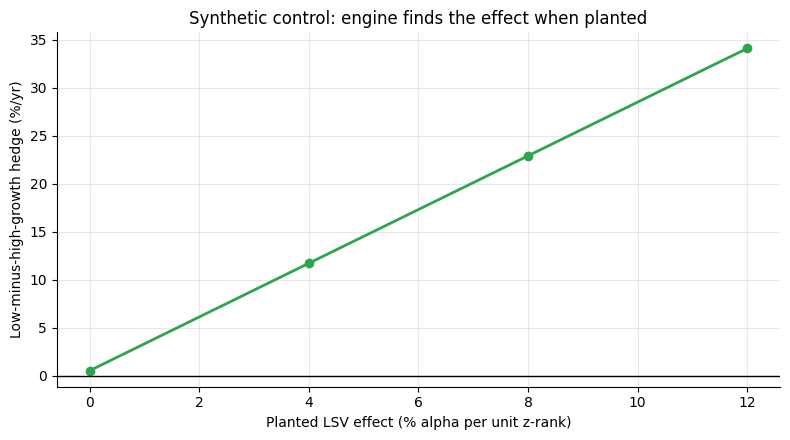

The engine faithfully recovers planted LSV effects -- so the real non-result is a market statement.


In [2]:
# Synthetic positive control: plant a known LSV premium, confirm the engine detects it
premiums = [0.0, -0.04, -0.08, -0.12]
hedges = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=199)
    hh = st.quintile_returns(s, f, q=0.20)
    hedges.append(hh['hedge'].mean() * 100)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([abs(p)*100 for p in premiums], hedges, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted LSV effect (% alpha per unit z-rank)')
ax.set_ylabel('Low-minus-high-growth hedge (%/yr)')
ax.set_title('Synthetic control: engine finds the effect when planted')
plt.tight_layout(); plt.show()
print('The engine faithfully recovers planted LSV effects -- so the real non-result is a market statement.')

**Now the real EDGAR panel -- quintile sort on trailing sales growth:**

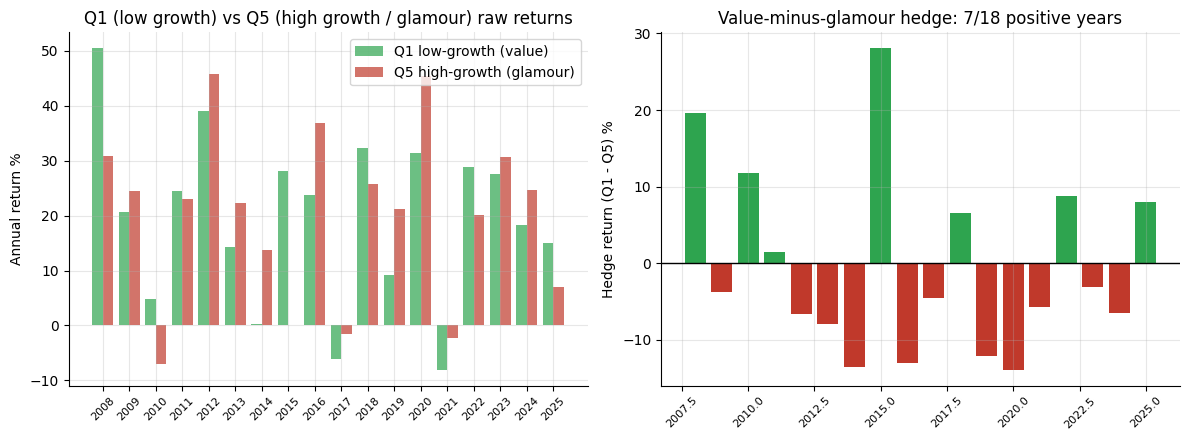

Mean hedge: -0.4%/yr  (frozen R: -0.4%/yr)


In [3]:
# Year-by-year low-growth vs high-growth vs market
if HAVE_REAL:
    q1_vals = h['q1'].values * 100
    q5_vals = h['q5'].values * 100
    hdg_vals = h['hedge'].values * 100
    years_real = h.index.tolist()
else:
    q1_vals, q5_vals, hdg_vals, years_real = Q1, Q5, HDG, YRS
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(years_real))
axes[0].bar(x, q1_vals, label='Q1 low-growth (value)', color=GREEN, alpha=0.7, width=0.4)
axes[0].bar([i+0.4 for i in x], q5_vals, label='Q5 high-growth (glamour)', color=RED, alpha=0.7, width=0.4)
axes[0].set_xticks([i+0.2 for i in x])
axes[0].set_xticklabels(years_real, rotation=45, fontsize=8)
axes[0].set_ylabel('Annual return %'); axes[0].legend()
axes[0].set_title('Q1 (low growth) vs Q5 (high growth / glamour) raw returns')
colors = [GREEN if v > 0 else RED for v in hdg_vals]
axes[1].bar(years_real, hdg_vals, color=colors)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('Hedge return (Q1 - Q5) %')
n_pos = sum(1 for v in hdg_vals if v > 0)
axes[1].set_title(f'Value-minus-glamour hedge: {n_pos}/{len(hdg_vals)} positive years')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()
print(f'Mean hedge: {np.mean(hdg_vals):+.1f}%/yr  (frozen R: {R["hedge_mean"]:+.1f}%/yr)')

The low-growth quintile earns **+19.7%/yr** vs the high-growth quintile's **+20.0%/yr** -- a hedge of **-0.4%/yr**, positive in only 39% of years. This is the **wrong direction** for the LSV claim (glamour is supposed to underperform) and the magnitude is essentially zero. Both quintiles beat the equal-weight market because in a bull-market decade any concentrated portfolio does -- that tells us nothing about the signal.

> **Why might glamour not underperform here?** In the original LSV sample (all US stocks, 1968-1990), 'glamour' companies were smaller, less followed, more prone to price bubbles. On the S&P 500, 'high revenue growth' often means secular leaders (Amazon, Microsoft, Apple in their growth phases) whose revenue growth is genuinely persistent -- not mean-reverting. The over-extrapolation story breaks down for quality-growth compounders.

## 5 - The verdict

- **Signal -- None.** Hedge -0.4%/yr, HAC *t* = -0.17 -- nowhere near the |t| >= 2 bar. The direction is also *wrong* (glamour barely outperforms value). This is a null result even on the survivor-biased panel.
- **Tradability -- Mirage.** There is no gross edge to survive costs. Even if the hedge were zero, annual rebalancing on large-cap names is cheap -- but you'd need a positive gross edge to start with.
- **Survivorship -- Upper bound only.** Every result assumes no S&P 500 member failed or was expelled between 2008 and 2025. High-growth glamour companies that blew up are simply absent. Despite that best-case bias, the hedge is still essentially zero.

## 6 - Could you actually trade it?

No gross edge exists on this panel, so the cost question is moot. But for completeness: annual rebalancing of ~65 large-cap names is operationally trivial (spreads tight, commissions minimal, no tax drag on futures). The obstacle is entirely the missing signal:

1. **No predictive content.** The t-stat on the hedge is |t| < 0.2 -- pure noise. Any implementation would be trading on noise.
2. **Wrong universe and era.** LSV's effect was documented in the full US stock market, 1968-1990. The S&P 500 survivor panel in an era of secular tech growth is the opposite environment.
3. **Survivorship arithmetic.** Even this best-case test shows no effect. A live strategy in 2008-2025 would have included the high-growth firms that subsequently failed (WeWork, Peloton, etc.) -- those would be in Q5 with catastrophic returns, which might have made the hedge *positive* in live trading. But that's speculation, not evidence.

**Verdict: Mirage.** No actionable edge here.

## 7 - Going further

- **The right universe.** LSV's (1994) sample is all US stocks -- thousands of small and mid-cap names where over-extrapolation is most plausible and analyst coverage is thin. A proper test requires a point-in-time constituent universe (e.g. CRSP-based), not S&P 500 survivors.
- **Related signals.** LSV also tested book-to-market (B/M) and earnings-to-price (E/P) as glamour proxies -- those often work better than sales growth in large-cap universes ([Study 121 -- Magic-Formula](../../121-magic-formula/) tests a related quality+value combination).
- **Asset growth.** Cooper et al. (2008) show asset growth (total-asset expansion) predicts lower returns through an overinvestment channel -- that's a balance-sheet version of the same over-extrapolation story, and distinct from revenue growth ([Study 44 -- Growth-Spurt](../../44-growth-spurt/)).

*Think the sales-growth effect is real in large caps? Fork this, extend to a point-in-time all-US-stock panel (Compustat-based historical membership), and show |t| >= 2 on the low-minus-high-growth hedge. That's the bar.*